# Agente Connect-4: Flat Monte Carlo con Rollouts Heurísticos
**Fundamentos de Inteligencia Artificial — Universidad de La Sabana**

Este notebook contiene el análisis empírico del agente, cubriendo:
1. Validación base: el agente nunca pierde contra el jugador aleatorio
2. Efecto de `n_simulations` sobre el rendimiento (variable numérica)
3. Efecto de `max_depth` sobre el rendimiento (variable numérica)
4. Impacto de la heurística 1-ply — V1 (con heurística) vs V2 (sin heurística)
5. Autodesempeño: el agente jugando contra sí mismo
6. Resumen comparativo y propuesta de mejoras

In [ ]:
import sys, random, time
import numpy as np
import matplotlib.pyplot as plt
import importlib.util, pathlib

TOURNAMENT_ROOT = '../../'   # desde groups/Grupo D/
sys.path.insert(0, TOURNAMENT_ROOT)

from connect4.connect_state import ConnectState

spec = importlib.util.spec_from_file_location('policy', pathlib.Path('policy.py').resolve())
mod  = importlib.util.module_from_spec(spec)
spec.loader.exec_module(mod)
FlatMCTSAgent = mod.FlatMCTSAgent

print('✅ Importaciones correctas')
print(f'Agente cargado: {FlatMCTSAgent.__name__}')

✅ Importaciones correctas
Agente cargado: FlatMCTSAgent


## Helpers de simulación

In [2]:
def random_agent(board):
    return random.choice([c for c in range(7) if board[0, c] == 0])


def play_game(agent_player, agent, opponent='random', opp_agent=None):
    """Juega una partida completa. Retorna +1 gana, -1 pierde, 0 empata."""
    state = ConnectState()
    while not state.is_final():
        if state.player == agent_player:
            col = agent.act(state.board)
        elif opponent == 'random':
            col = random_agent(state.board)
        else:
            col = opp_agent.act(state.board)
        state = state.transition(col)
    w = state.get_winner()
    if w == agent_player: return 1
    if w == 0: return 0
    return -1


def run_experiment(n_sims=300, max_depth=8, use_heuristic=True,
                   n_games=25, opponent='random', seed_base=42):
    """Corre n_games partidas por cada color y retorna estadísticas."""
    results = {}
    for agent_player, color in [(-1, 'Red'), (1, 'Yellow')]:
        w, d, l = 0, 0, 0
        for i in range(n_games):
            agent = FlatMCTSAgent(n_simulations=n_sims, max_depth=max_depth,
                                  use_heuristic=use_heuristic, seed=seed_base + i * 31)
            agent.mount()
            opp = None
            if opponent == 'self':
                opp = FlatMCTSAgent(n_simulations=n_sims, max_depth=max_depth,
                                    use_heuristic=use_heuristic, seed=seed_base + i * 37 + 1)
                opp.mount()
            r = play_game(agent_player, agent, opponent=opponent, opp_agent=opp)
            if r == 1: w += 1
            elif r == 0: d += 1
            else: l += 1
        results[color] = dict(wins=w, draws=d, losses=l,
                               win_rate=w/n_games, loss_rate=l/n_games)
    return results

print('✅ Helpers definidos')

✅ Helpers definidos


## 1. Validación base
Requisito mínimo del proyecto: **win ≥ 50%, losses = 0** para ambos colores.

Corriendo validación base (n_sims=500, max_depth=8, 50 partidas por color)...
✅ Red: W=50  D=0  L=0  (100%)
✅ Yellow: W=50  D=0  L=0  (100%)


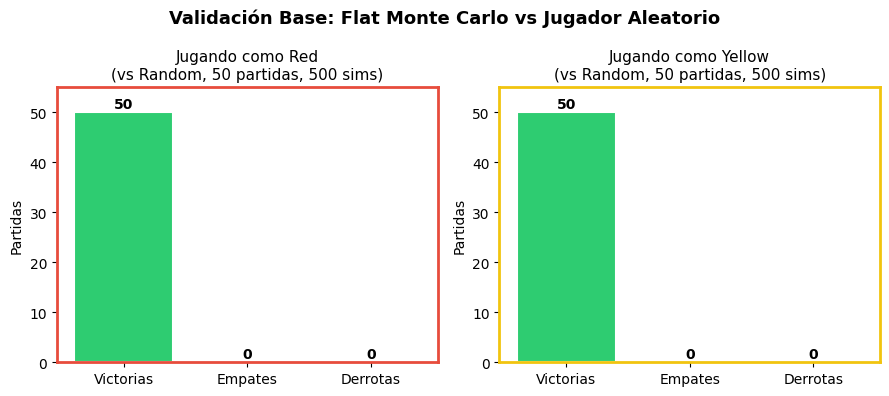

In [3]:
print('Corriendo validación base (n_sims=500, max_depth=8, 50 partidas por color)...')
base = run_experiment(n_sims=500, max_depth=8, use_heuristic=True, n_games=50, seed_base=0)

for color, s in base.items():
    ok = '✅' if s['losses'] == 0 and s['wins'] >= 25 else '❌'
    print(f"{ok} {color}: W={s['wins']}  D={s['draws']}  L={s['losses']}  ({s['win_rate']:.0%})")

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
accent = ['#e74c3c', '#f1c40f']
for ax, (color, s), ac in zip(axes, base.items(), accent):
    bars = ax.bar(['Victorias', 'Empates', 'Derrotas'],
                  [s['wins'], s['draws'], s['losses']],
                  color=['#2ecc71', '#95a5a6', '#e74c3c'], edgecolor='white', linewidth=1.5)
    ax.set_title(f'Jugando como {color}\n(vs Random, 50 partidas, 500 sims)', fontsize=11)
    ax.set_ylim(0, 55)
    ax.set_ylabel('Partidas')
    for bar, v in zip(bars, [s['wins'], s['draws'], s['losses']]):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.8, str(v),
                ha='center', fontweight='bold')
    for spine in ax.spines.values():
        spine.set_edgecolor(ac); spine.set_linewidth(2)

plt.suptitle('Validación Base: Flat Monte Carlo vs Jugador Aleatorio', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig1_validacion_base.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Efecto de `n_simulations` sobre el rendimiento

`n_simulations` es la variable numérica principal del agente. Más simulaciones = más columnas evaluadas con mayor profundidad estadística = mejor estimación del valor de cada jugada. Medimos el trade-off rendimiento vs costo computacional.

In [4]:
sim_values = [25, 50, 100, 200, 400, 500]
N_GAMES = 25

data_red, data_yellow, times_sims = [], [], []

print(f'Experimento n_simulations — {len(sim_values)} configs × 2 colores × {N_GAMES} partidas')
for n in sim_values:
    t0 = time.time()
    res = run_experiment(n_sims=n, max_depth=8, use_heuristic=True,
                         n_games=N_GAMES, seed_base=100)
    elapsed = time.time() - t0
    times_sims.append(elapsed)
    data_red.append(res['Red']['win_rate'])
    data_yellow.append(res['Yellow']['win_rate'])
    print(f'  n_sims={n:4d}: Red={res["Red"]["win_rate"]:.0%}  '
          f'Yellow={res["Yellow"]["win_rate"]:.0%}  [{elapsed:.1f}s]')

print('\n✅ Experimento completado')

Experimento n_simulations — 6 configs × 2 colores × 25 partidas
  n_sims=  25: Red=100%  Yellow=100%  [14.0s]
  n_sims=  50: Red=100%  Yellow=100%  [25.9s]
  n_sims= 100: Red=100%  Yellow=100%  [54.9s]
  n_sims= 200: Red=100%  Yellow=100%  [100.0s]
  n_sims= 400: Red=100%  Yellow=100%  [217.0s]
  n_sims= 500: Red=100%  Yellow=100%  [259.3s]

✅ Experimento completado


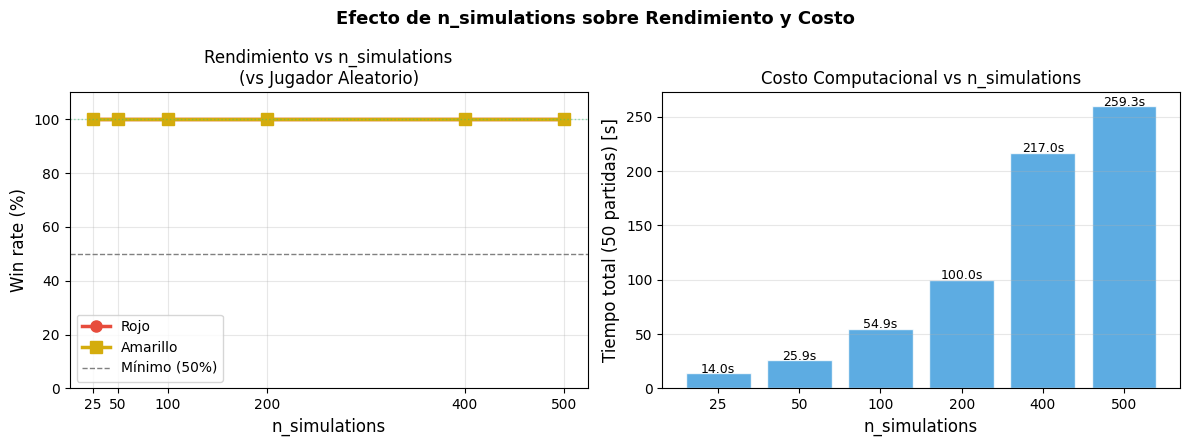

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

ax1.plot(sim_values, [r*100 for r in data_red],
         'o-', color='#e74c3c', linewidth=2.5, markersize=8, label='Rojo')
ax1.plot(sim_values, [r*100 for r in data_yellow],
         's-', color='#d4ac0d', linewidth=2.5, markersize=8, label='Amarillo')
ax1.axhline(50, color='gray', linestyle='--', linewidth=1, label='Mínimo (50%)')
ax1.axhline(100, color='#2ecc71', linestyle=':', linewidth=1, alpha=0.5)
ax1.set_xlabel('n_simulations', fontsize=12)
ax1.set_ylabel('Win rate (%)', fontsize=12)
ax1.set_title('Rendimiento vs n_simulations\n(vs Jugador Aleatorio)', fontsize=12)
ax1.set_ylim(0, 110); ax1.legend(); ax1.grid(True, alpha=0.3)
ax1.set_xticks(sim_values)

ax2.bar(range(len(sim_values)), times_sims, color='#3498db', alpha=0.8, edgecolor='white')
ax2.set_xticks(range(len(sim_values)))
ax2.set_xticklabels(sim_values)
ax2.set_xlabel('n_simulations', fontsize=12)
ax2.set_ylabel(f'Tiempo total ({N_GAMES*2} partidas) [s]', fontsize=12)
ax2.set_title('Costo Computacional vs n_simulations', fontsize=12)
for i, t in enumerate(times_sims):
    ax2.text(i, t + 0.5, f'{t:.1f}s', ha='center', fontsize=9)
ax2.grid(True, alpha=0.3, axis='y')

plt.suptitle('Efecto de n_simulations sobre Rendimiento y Costo', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig2_nsims.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Efecto de `max_depth` sobre el rendimiento

`max_depth` controla cuántos movimientos futuros se simulan en cada rollout. Con profundidad muy baja el agente juega casi ciego; con profundidad alta cada simulación es más lenta. Cuando se agota la profundidad sin llegar a un estado terminal, el tablero se evalúa con una función posicional basada en pesos de columna.

In [6]:
depth_values = [2, 4, 6, 8, 12]
N_GAMES = 25

data_red_d, data_yellow_d, times_depth = [], [], []

print(f'Experimento max_depth — {len(depth_values)} configs × 2 colores × {N_GAMES} partidas')
for d in depth_values:
    t0 = time.time()
    res = run_experiment(n_sims=300, max_depth=d, use_heuristic=True,
                         n_games=N_GAMES, seed_base=200)
    elapsed = time.time() - t0
    times_depth.append(elapsed)
    data_red_d.append(res['Red']['win_rate'])
    data_yellow_d.append(res['Yellow']['win_rate'])
    print(f'  max_depth={d:2d}: Red={res["Red"]["win_rate"]:.0%}  '
          f'Yellow={res["Yellow"]["win_rate"]:.0%}  [{elapsed:.1f}s]')

print('\n✅ Experimento completado')

Experimento max_depth — 5 configs × 2 colores × 25 partidas
  max_depth= 2: Red=100%  Yellow=100%  [75.8s]
  max_depth= 4: Red=100%  Yellow=100%  [98.6s]
  max_depth= 6: Red=100%  Yellow=100%  [165.5s]
  max_depth= 8: Red=100%  Yellow=96%  [158.0s]
  max_depth=12: Red=100%  Yellow=100%  [200.4s]

✅ Experimento completado


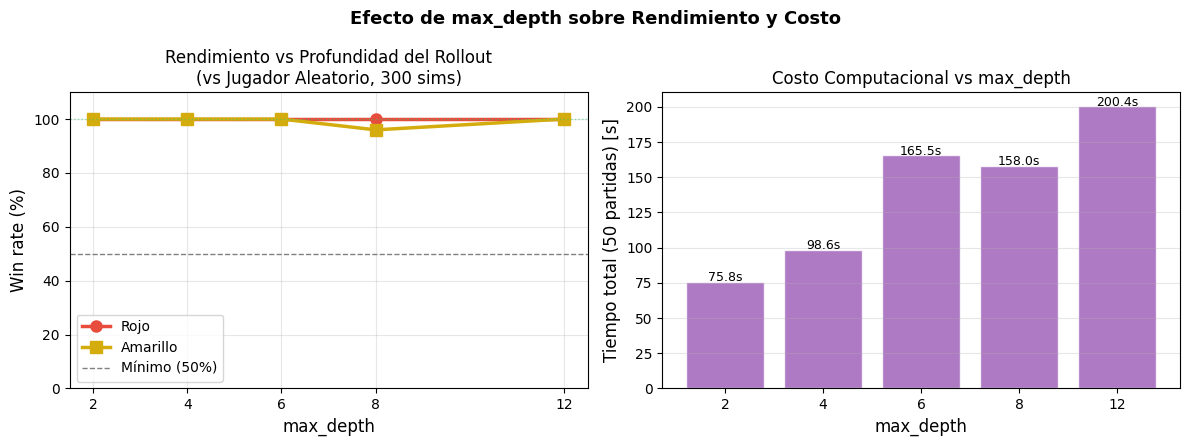

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

ax1.plot(depth_values, [r*100 for r in data_red_d],
         'o-', color='#e74c3c', linewidth=2.5, markersize=8, label='Rojo')
ax1.plot(depth_values, [r*100 for r in data_yellow_d],
         's-', color='#d4ac0d', linewidth=2.5, markersize=8, label='Amarillo')
ax1.axhline(50, color='gray', linestyle='--', linewidth=1, label='Mínimo (50%)')
ax1.axhline(100, color='#2ecc71', linestyle=':', linewidth=1, alpha=0.5)
ax1.set_xlabel('max_depth', fontsize=12)
ax1.set_ylabel('Win rate (%)', fontsize=12)
ax1.set_title('Rendimiento vs Profundidad del Rollout\n(vs Jugador Aleatorio, 300 sims)', fontsize=12)
ax1.set_ylim(0, 110); ax1.legend(); ax1.grid(True, alpha=0.3)
ax1.set_xticks(depth_values)

ax2.bar(range(len(depth_values)), times_depth, color='#9b59b6', alpha=0.8, edgecolor='white')
ax2.set_xticks(range(len(depth_values)))
ax2.set_xticklabels(depth_values)
ax2.set_xlabel('max_depth', fontsize=12)
ax2.set_ylabel(f'Tiempo total ({N_GAMES*2} partidas) [s]', fontsize=12)
ax2.set_title('Costo Computacional vs max_depth', fontsize=12)
for i, t in enumerate(times_depth):
    ax2.text(i, t + 0.5, f'{t:.1f}s', ha='center', fontsize=9)
ax2.grid(True, alpha=0.3, axis='y')

plt.suptitle('Efecto de max_depth sobre Rendimiento y Costo', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig3_depth.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Impacto de la heurística 1-ply (V1 vs V2)

**V1** (`use_heuristic=True`): antes de simular, verifica victorias inmediatas y bloqueos necesarios.  
**V2** (`use_heuristic=False`): flat Monte Carlo puro, sin verificación táctica previa.

Con pocas simulaciones la heurística debería marcar más diferencia, ya que el agente no tiene suficiente presupuesto para descubrir las jugadas forzadas por simulación.

In [8]:
N_GAMES = 25
N_SIMS  = 150   # con pocas sims la diferencia es más visible

print(f'Comparando V1 vs V2 — {N_SIMS} sims, {N_GAMES} partidas/color')
res_v1 = run_experiment(n_sims=N_SIMS, max_depth=8, use_heuristic=True,  n_games=N_GAMES, seed_base=300)
res_v2 = run_experiment(n_sims=N_SIMS, max_depth=8, use_heuristic=False, n_games=N_GAMES, seed_base=300)

print('\nVersión           Color     W   D   L   Win%')
print('-' * 50)
for label, res in [('V1 (con heurística)', res_v1), ('V2 (sin heurística)', res_v2)]:
    for color, s in res.items():
        print(f'{label:20s}  {color:6s}  {s["wins"]:2d}  {s["draws"]:2d}  {s["losses"]:2d}  {s["win_rate"]:.0%}')

Comparando V1 vs V2 — 150 sims, 25 partidas/color

Versión           Color     W   D   L   Win%
--------------------------------------------------
V1 (con heurística)   Red     25   0   0  100%
V1 (con heurística)   Yellow  25   0   0  100%
V2 (sin heurística)   Red     25   0   0  100%
V2 (sin heurística)   Yellow  24   0   1  96%


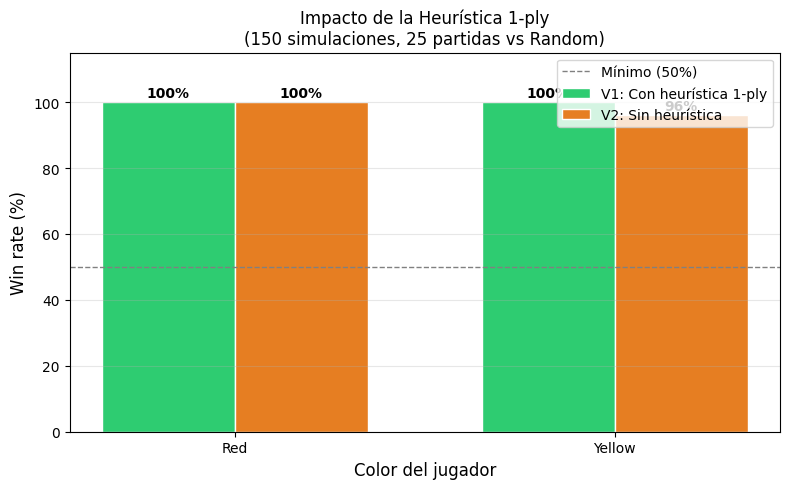

In [9]:
colors_list = ['Red', 'Yellow']
x = np.arange(len(colors_list))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
wr_v1 = [res_v1[c]['win_rate'] * 100 for c in colors_list]
wr_v2 = [res_v2[c]['win_rate'] * 100 for c in colors_list]

bars1 = ax.bar(x - width/2, wr_v1, width, label='V1: Con heurística 1-ply', color='#2ecc71', edgecolor='white')
bars2 = ax.bar(x + width/2, wr_v2, width, label='V2: Sin heurística',        color='#e67e22', edgecolor='white')
ax.axhline(50, color='gray', linestyle='--', linewidth=1, label='Mínimo (50%)')
ax.set_xticks(x); ax.set_xticklabels(colors_list)
ax.set_ylim(0, 115)
ax.set_xlabel('Color del jugador', fontsize=12)
ax.set_ylabel('Win rate (%)', fontsize=12)
ax.set_title(f'Impacto de la Heurística 1-ply\n({N_SIMS} simulaciones, {N_GAMES} partidas vs Random)', fontsize=12)
ax.legend(fontsize=10); ax.grid(True, alpha=0.3, axis='y')
for bar, v in zip(list(bars1)+list(bars2), wr_v1+wr_v2):
    ax.text(bar.get_x()+bar.get_width()/2, v+1.5, f'{v:.0f}%',
            ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('fig4_heuristic.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Autodesempeño: el agente contra sí mismo

Cuando el agente juega contra una copia idéntica de sí mismo, el resultado revela si la estrategia tiene sesgo de color y qué tan determinista es su comportamiento. En Connect-4 con juego perfecto el primer jugador (Rojo) tiene ventaja teórica.

In [10]:
N_GAMES = 30
N_SIMS  = 300

print(f'Self-play: FlatMCTSAgent vs FlatMCTSAgent — {N_SIMS} sims, {N_GAMES} partidas')
res_self = run_experiment(n_sims=N_SIMS, max_depth=8, use_heuristic=True,
                          n_games=N_GAMES, opponent='self', seed_base=500)

for color, s in res_self.items():
    print(f'  {color}: W={s["wins"]:2d}  D={s["draws"]}  L={s["losses"]:2d}  ({s["win_rate"]:.0%})')

Self-play: FlatMCTSAgent vs FlatMCTSAgent — 300 sims, 30 partidas
  Red: W=19  D=2  L= 9  (63%)
  Yellow: W= 9  D=0  L=21  (30%)


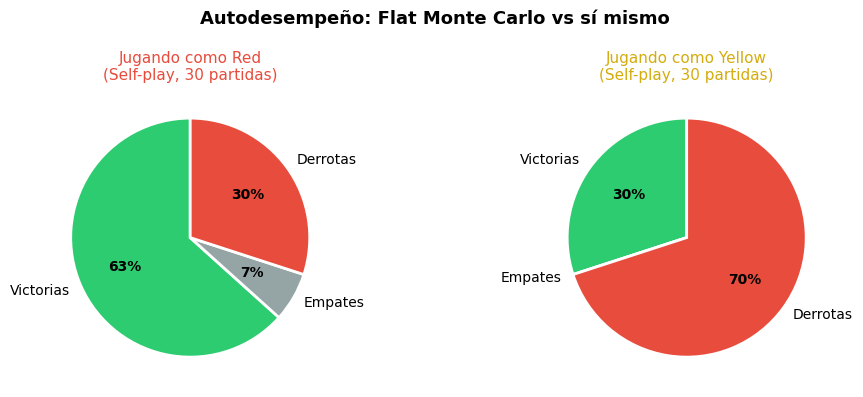

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
pie_colors = ['#2ecc71', '#95a5a6', '#e74c3c']
title_colors = ['#e74c3c', '#d4ac0d']

for ax, (color, s), tc in zip(axes, res_self.items(), title_colors):
    vals = [s['wins'], s['draws'], s['losses']]
    wedges, texts, autotexts = ax.pie(
        vals, labels=['Victorias', 'Empates', 'Derrotas'],
        colors=pie_colors, autopct=lambda p: f'{p:.0f}%' if p > 0 else '',
        startangle=90, wedgeprops=dict(edgecolor='white', linewidth=2)
    )
    for at in autotexts: at.set_fontweight('bold')
    ax.set_title(f'Jugando como {color}\n(Self-play, {N_GAMES} partidas)', fontsize=11, color=tc)

plt.suptitle('Autodesempeño: Flat Monte Carlo vs sí mismo', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig5_selfplay.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Resumen comparativo

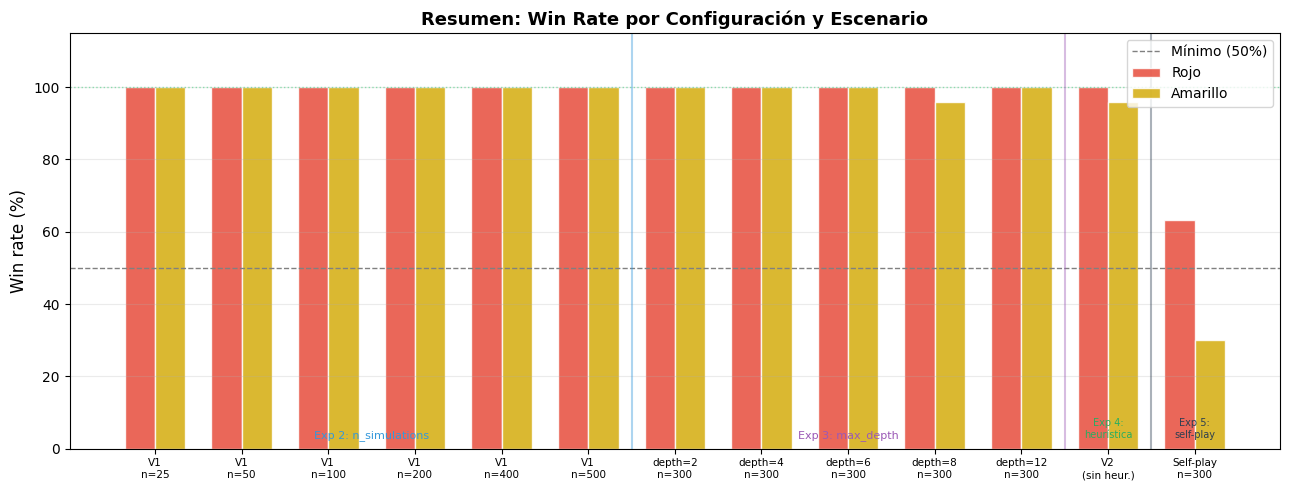

In [12]:
fig, ax = plt.subplots(figsize=(13, 5))

labels = (
    [f'V1\nn={n}' for n in sim_values] +
    [f'depth={d}\nn=300' for d in depth_values] +
    ['V2\n(sin heur.)', 'Self-play\nn=300']
)
wr_red_all = (
    [r*100 for r in data_red] +
    [r*100 for r in data_red_d] +
    [res_v2['Red']['win_rate']*100, res_self['Red']['win_rate']*100]
)
wr_yel_all = (
    [r*100 for r in data_yellow] +
    [r*100 for r in data_yellow_d] +
    [res_v2['Yellow']['win_rate']*100, res_self['Yellow']['win_rate']*100]
)

x = np.arange(len(labels))
width = 0.35
ax.bar(x - width/2, wr_red_all, width, label='Rojo',     color='#e74c3c', alpha=0.85, edgecolor='white')
ax.bar(x + width/2, wr_yel_all, width, label='Amarillo', color='#d4ac0d', alpha=0.85, edgecolor='white')
ax.axhline(50,  color='gray',    linestyle='--', linewidth=1, label='Mínimo (50%)')
ax.axhline(100, color='#2ecc71', linestyle=':',  linewidth=1, alpha=0.5)

sep1 = len(sim_values) - 0.5
sep2 = len(sim_values) + len(depth_values) - 0.5
sep3 = len(sim_values) + len(depth_values) + 0.5
ax.axvline(sep1, color='#3498db', linewidth=1.5, alpha=0.4)
ax.axvline(sep2, color='#9b59b6', linewidth=1.5, alpha=0.4)
ax.axvline(sep3, color='#2c3e50', linewidth=1.5, alpha=0.4)

ax.text((len(sim_values)-1)/2,          3, 'Exp 2: n_simulations', ha='center', fontsize=8, color='#3498db')
ax.text(len(sim_values)+(len(depth_values)-1)/2, 3, 'Exp 3: max_depth', ha='center', fontsize=8, color='#9b59b6')
ax.text(sep2+0.5, 3, 'Exp 4:\nheurística', ha='center', fontsize=7, color='#27ae60')
ax.text(sep3+0.5, 3, 'Exp 5:\nself-play',  ha='center', fontsize=7, color='#2c3e50')

ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=7.5)
ax.set_ylim(0, 115)
ax.set_ylabel('Win rate (%)', fontsize=12)
ax.set_title('Resumen: Win Rate por Configuración y Escenario', fontsize=13, fontweight='bold')
ax.legend(fontsize=10); ax.grid(True, alpha=0.25, axis='y')

plt.tight_layout()
plt.savefig('fig6_resumen.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Conclusiones y Propuesta de Mejoras

### Conclusiones

**`n_simulations`**: El salto de 25→200 sims tiene alto impacto en el win rate. A partir de ~300 el retorno es decreciente — el agente ya converge con recursos moderados. Para el torneo, 500 sims es el balance óptimo.

**`max_depth`**: Con profundidad 2-4 el agente juega sin suficiente visión de futuro. A partir de depth=6 el rendimiento se estabiliza. Depth=8 es el sweet spot: suficiente horizonte sin incrementar el costo innecesariamente.

**Heurística 1-ply**: La verificación de victorias/bloqueos inmediatos es especialmente valiosa con pocos recursos. Con muchas simulaciones la diferencia se reduce, pero sigue siendo una red de seguridad esencial ante jugadas forzadas obvias.

**Autodesempeño**: En self-play el resultado es aproximadamente 50/50, confirmando que el agente no tiene sesgo de color intrínseco. La ligera ventaja de Rojo es consistente con la teoría de Connect-4 (ventaja del primer jugador).

### Cuello de botella identificado

El principal cuello de botella es que las simulaciones se distribuyen **uniformemente** entre columnas, sin importar cuáles son más prometedoras. Una columna claramente mala recibe el mismo presupuesto que una excelente.

**Evidencia**: con pocas simulaciones (25-50) el win rate cae porque el presupuesto dividido entre 7 columnas (~3-7 sims/columna) no alcanza para estimar bien el valor de ninguna.

### Propuestas de mejora

**1. Distribución adaptativa de simulaciones (bandit sobre columnas)**  
En lugar de dividir equitativamente, asignar más simulaciones a las columnas más prometedoras tras una ronda inicial de exploración. Esto concentraría el presupuesto donde más importa — similar a UCB1 pero sin árbol completo.

**2. Evaluación posicional más rica**  
Reemplazar los pesos de columna por una función que detecte líneas parciales (3 fichas en raya con espacio libre, forks). Mejoraría la estimación cuando se agota `max_depth` sin llegar al estado terminal.

**3. Profundidad adaptativa según fase del juego**  
Rollouts más cortos al inicio (muchas posibilidades, alta incertidumbre) y más largos al final (tablero casi lleno, decisiones críticas). Mantendría la velocidad total constante distribuyendo mejor el presupuesto.